--- 5 Dòng dữ liệu đầu tiên từ file gốc ---
   STT   T1   L1   H1   S1   V1   X1   D1   N1   T2  ...   X6   D6   N6  GT  \
0    1  7.2  7.3  6.3  7.3  7.0  7.9  7.3  5.5  8.4  ...  6.6  7.6  5.9   F   
1    2  5.4  3.9  3.9  4.0  5.4  5.4  5.3  2.8  6.3  ...  6.6  6.1  4.4   M   
2    3  5.6  6.8  7.2  7.5  4.3  7.4  5.8  3.2  5.0  ...  7.9  8.1  4.6   M   
3    4  6.6  6.4  5.3  6.9  5.4  7.3  6.4  5.8  5.1  ...  7.1  7.3  7.4   M   
4    5  6.0  5.0  6.0  7.3  6.5  7.7  7.9  6.1  5.4  ...  6.1  7.5  7.2   M   

   DT   KV   DH1   DH2   DH3  KT  
0 NaN  2NT  3.25  3.25  4.50  A1  
1 NaN    1  6.00  4.00  3.50   C  
2 NaN    1  5.00  6.75  4.00   C  
3 NaN    1  4.25  4.25  5.25  D1  
4 NaN  2NT  4.25  4.50  5.00   A  

[5 rows x 56 columns]

=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN ===
Kích thước tập Huấn luyện (X_train_scaled): (80, 5)
Kích thước tập Kiểm định  (X_val_scaled):   (20, 5)

--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN MÔ HÌNH BẰNG GRADIENT DESCENT ---
Vòng lặp  10/100 | Sai số tập H

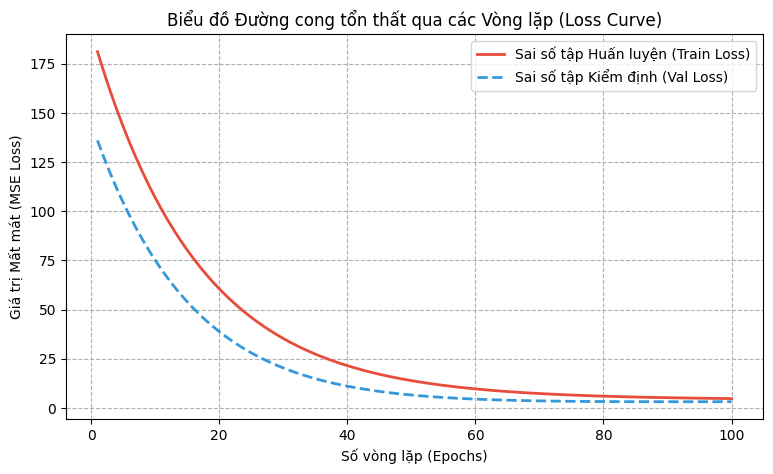


=== KẾT QUẢ TRỌNG SỐ TỐI ƯU CUỐI CÙNG CỦA MÔ HÌNH ===
Hệ số chặn tự do (Bias - b): 8.2252

Danh sách các Trọng số tương ứng với từng biến đầu vào (Weights - W):
 -> Trọng số của đặc trưng [T6   ]: +0.5745
 -> Trọng số của đặc trưng [L6   ]: -0.0063
 -> Trọng số của đặc trưng [H6   ]: +0.1396
 -> Trọng số của đặc trưng [GT_F ]: +4.5573
 -> Trọng số của đặc trưng [GT_M ]: +3.8707


In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# BƯỚC 1: CHUẨN BỊ DỮ LIỆU -> LÀM SẠCH DỮ LIỆU (Theo sơ đồ trên bảng)
# Nạp dữ liệu bảng xét tuyển đại học trực tiếp từ đường dẫn GitHub hệ thống
url = "https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/dulieuxettuyendaihoc.csv"
df = pd.read_csv(url)

print("--- 5 Dòng dữ liệu đầu tiên từ file gốc ---")
print(df.head())

# Định nghĩa các đặc trưng đầu vào (Features)
features_numeric = ['T6', 'L6', 'H6']   # Biến liên tục: Điểm Toán, Lý, Hóa học kỳ 2 lớp 12
features_categorical = ['GT']             # Biến danh mục: Giới tính (F/M)
target_column = 'TONG_DIEM_DH'            # Biến liên tục mục tiêu cần dự đoán

# Tính tổng điểm thi đại học thực tế của 3 môn (DH1 + DH2 + DH3) làm giá y
df[target_column] = df['DH1'] + df['DH2'] + df['DH3']

# Làm sạch dữ liệu: Loại bỏ tất cả dòng có chứa giá trị khuyết thiếu (NaN) ở các cột quan trọng
df = df.dropna(subset=features_numeric + features_categorical + [target_column])

# Tách biệt ma trận đặc trưng X và vector mục tiêu y
X = df[features_numeric + features_categorical]
y = df[target_column].values.astype(np.float32) # Chuyển target về float32 để đồng bộ tính toán với TensorFlow


# BƯỚC 2: CHIA DỮ LIỆU (TRAIN - VAL) & TIỀN XỬ LÝ (TUÂN THỦ CHỐNG DATA LEAKAGE)
# Quy tắc vàng: Phân rã chia tách dữ liệu TRƯỚC KHI thực hiện bất kỳ bước ép dải nào!
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Xây dựng bộ tiền xử lý đồng bộ ColumnTransformer:
# - Cột số: Chuẩn hóa StandardScaler (Z-score) đưa về phân phối có mean=0, std=1
# - Cột chữ: Mã hóa OneHotEncoder giúp chuyển chuỗi (M/F) thành số nhị phân (0/1)
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), features_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), features_categorical)
])

# Theo đúng sơ đồ bài giảng: Scaler thực hiện fit_transform trên Train và chỉ transform trên Val
X_train_scaled = preprocessor.fit_transform(X_train).astype(np.float32)
X_val_scaled = preprocessor.transform(X_val).astype(np.float32)

print("\n=== KẾT QUẢ KIỂM TRA KÍCH THƯỚC MA TRẬN ===")
print(f"Kích thước tập Huấn luyện (X_train_scaled): {X_train_scaled.shape}")
print(f"Kích thước tập Kiểm định  (X_val_scaled):   {X_val_scaled.shape}\n")


# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH LINEAR REGRESSION + GRADIENT DESCENT (TENSORFLOW)
# Lấy số lượng đặc trưng đầu vào sau khi ma trận đã được mở rộng mã hóa (5 cột)
input_dim = X_train_scaled.shape[1]

# Lấy danh sách tên các đặc trưng sau biến đổi để hiển thị trọng số rõ ràng
feature_names = features_numeric + list(preprocessor.named_transformers_['cat'].get_feature_names_out(features_categorical))

# Khởi tạo các biến trọng số W ngẫu nhiên và bias b bằng 0
W = tf.Variable(tf.random.normal([input_dim, 1]), name='weights')
b = tf.Variable(tf.zeros([1]), name='bias')

# Cấu hình các siêu tham số tối ưu hóa
learning_rate = 0.01
epochs = 100

# Khởi tạo các danh sách lưu trữ lịch sử để vẽ đồ thị tổn thất (Loss Curve)
train_loss_history = []
val_loss_history = []

print("--- BẮT ĐẦU QUÁ TRÌNH HUẤN LUYỆN MÔ HÌNH BẰNG GRADIENT DESCENT ---")

for epoch in range(1, epochs + 1):
    # Sử dụng tf.GradientTape để theo dõi và tự động tính toán đạo hàm riêng (Gradients)
    with tf.GradientTape() as tape:
        # 1. Dự đoán giá trị điểm số dựa trên phương trình hồi quy tuyến tính: y_pred = X * W + b
        y_train_pred = tf.matmul(X_train_scaled, W) + b
        # 2. Tính toán hàm mất mát bằng Sai số bình phương trung bình (MSE - Mean Squared Error) [cite: 1897]
        train_loss = tf.reduce_mean(tf.square(y_train_pred - y_train.reshape(-1, 1)))

    # 3. Tính toán Gradients (đạo hàm riêng) của hàm Loss đối với các biến tham số W và b
    dW, db = tape.gradient(train_loss, [W, b])

    # 4. Cập nhật các trọng số và bias ngược chiều Gradient theo thuật toán Gradient Descent [cite: 1902]
    W.assign_sub(learning_rate * dW)
    b.assign_sub(learning_rate * db)

    # 5. Tính toán sai số (Loss) trên tập Kiểm định độc lập để theo dõi quá trình hội tụ
    y_val_pred = tf.matmul(X_val_scaled, W) + b
    val_loss = tf.reduce_mean(tf.square(y_val_pred - y_val.reshape(-1, 1)))

    # Lưu lại giá trị lịch sử của từng Epoch phục vụ vẽ biểu đồ đồ thị
    train_loss_history.append(train_loss.numpy())
    val_loss_history.append(val_loss.numpy())

    # In kết quả theo dõi tiến trình rõ ràng bằng tiếng Việt sau mỗi 10 vòng lặp
    if epoch % 10 == 0:
        print(f"Vòng lặp {epoch:3d}/{epochs} | Sai số tập Học (Train Loss): {train_loss.numpy():.4f} | Sai số tập Kiểm định (Val Loss): {val_loss.numpy():.4f}")


# BƯỚC 4: TRỰC QUAN HÓA: VẼ ĐỒ THỊ LOSS CURVE (Giống hình vẽ trên bảng)
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_loss_history, label='Sai số tập Huấn luyện (Train Loss)', color='#e74c3c', linewidth=2)
plt.plot(range(1, epochs + 1), val_loss_history, label='Sai số tập Kiểm định (Val Loss)', color='#3498db', linewidth=2, linestyle='--')
plt.title('Biểu đồ Đường cong tổn thất qua các Vòng lặp (Loss Curve)')
plt.xlabel('Số vòng lặp (Epochs)')
plt.ylabel('Giá trị Mất mát (MSE Loss)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()


# BƯỚC 5: XUẤT KẾT QUẢ CÁC TRỌNG SỐ TỐI ƯU CUỐI CÙNG TÌM ĐƯỢC
print("\n=== KẾT QUẢ TRỌNG SỐ TỐI ƯU CUỐI CÙNG CỦA MÔ HÌNH ===")
print(f"Hệ số chặn tự do (Bias - b): {b.numpy()[0]:.4f}\n")
print("Danh sách các Trọng số tương ứng với từng biến đầu vào (Weights - W):")
for name, weight in zip(feature_names, W.numpy().flatten()):
    print(f" -> Trọng số của đặc trưng [{name:5s}]: {weight:+.4f}")

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.datasets import cifar10

# 1. Tải bộ dữ liệu CIFAR-10 tích hợp sẵn trong TensorFlow
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# 2. Làm phẳng ma trận ảnh 3D (32x32x3 = 3072) và chuẩn hóa dải pixel về [0, 1]
X_train_flat = X_train.reshape(-1, 32 * 32 * 3) / 255.0
X_test_flat = X_test.reshape(-1, 32 * 32 * 3) / 255.0

# 3. Thiết lập cấu trúc mạng ANN phức hợp chống Overfitting
cifar_model = Sequential([
    Input(shape=(32 * 32 * 3,)),
    Dense(512, activation='relu'),
    Dropout(0.3),  # Giảm thiểu quá khớp cho tập dữ liệu ảnh phức tạp
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # Đầu ra 10 lớp đại diện cho các nhãn
])

# 4. Biên dịch mô hình
cifar_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # Phù hợp với nhãn số nguyên từ 0 -> 9
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình
print("--- Bắt đầu huấn luyện mạng ANN trên CIFAR-10 ---")
cifar_model.fit(X_train_flat, y_train, validation_split=0.2, epochs=15, batch_size=64, verbose=1)

# 6. Đánh giá độ chính xác thực tế
loss, accuracy = cifar_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\n=> [CIFAR-10] Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
--- Bắt đầu huấn luyện mạng ANN trên CIFAR-10 ---
Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.2333 - loss: 2.0592 - val_accuracy: 0.2666 - val_loss: 1.9793
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.2922 - loss: 1.9201 - val_accuracy: 0.3450 - val_loss: 1.8447
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.3086 - loss: 1.8787 - val_accuracy: 0.3571 - val_loss: 1.8013
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.3258 - loss: 1.8376 - val_accuracy: 0.3523 - val_loss: 1.7902
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.3314 - loss: 1.8210 - val_accuracy: 0.3704 - val_loss: 1.7616
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3412 - loss: 1.8035 - val_accuracy: 0.3731 - val_loss: 1.7707
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3486 - loss: 1.7829 - val_accuracy: 0.3768 - val_

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.datasets import mnist

# 1. Tải bộ dữ liệu ảnh chữ số viết tay MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Làm phẳng ảnh ma trận 2D về vector phẳng 1D (28x28 = 784) và chuẩn hóa dải điểm ảnh
X_train_flat = X_train.reshape(-1, 784) / 255.0
X_test_flat = X_test.reshape(-1, 784) / 255.0

# 3. Cấu trúc mạng ANN theo quy chuẩn tài liệu thực hành
mnist_model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 lớp đầu ra tương ứng từ Số 0 -> Số 9
])

# 4. Biên dịch mô hình
mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Huấn luyện mô hình
print("--- Bắt đầu huấn luyện mạng ANN trên MNIST ---")
mnist_model.fit(X_train_flat, y_train, validation_split=0.1, epochs=10, batch_size=128, verbose=1)

# 6. Đánh giá kiểm thử
loss, accuracy = mnist_model.evaluate(X_test_flat, y_test, verbose=0)
print(f"\n=> [MNIST] Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Bắt đầu huấn luyện mạng ANN trên MNIST ---
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9053 - loss: 0.3231 - val_accuracy: 0.9662 - val_loss: 0.1159
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9610 - loss: 0.1303 - val_accuracy: 0.9745 - val_loss: 0.0842
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9705 - loss: 0.0938 - val_accuracy: 0.9742 - val_loss: 0.0802
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9779 - loss: 0.0717 - val_accuracy: 0.9755 - val_loss: 0.0738
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9806 - loss: 0.0598 - val_accuracy: 0.9787 - val_loss: 0.0712
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9836 - loss: 0.0508 - val_accuracy: 0.9810 - val_loss: 0.0704
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9857 - loss: 0.0433 - val_accuracy: 0.9813 - val_loss: 0.0720
Epoc

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Đọc tải tệp mảng dữ liệu numpy (Kích thước giả định ban đầu là 200x200x3)
try:
    photos = np.load('dogs_vs_cats_photos.npy')
    labels = np.load('dogs_vs_cats_labels.npy')
except FileNotFoundError:
    print("Không tìm thấy tệp .npy, tự động tạo dữ liệu mẫu ngẫu nhiên để demo code...")
    photos = np.random.randint(0, 255, size=(100, 150, 150, 3), dtype=np.uint8)
    labels = np.random.choice([0.0, 1.0], size=(100,))  # 0: Mèo, 1: Chó

# 2. Biến đổi làm phẳng cấu trúc đa chiều của ảnh về dạng vector phẳng 1 chiều
num_samples, h, w, c = photos.shape
photos_flat = photos.reshape(num_samples, h * w * c)

# 3. Áp dụng quy tắc vàng: Chia tập dữ liệu trước khi xử lý (Split First)
X_train, X_test, y_train, y_test = train_test_split(photos_flat, labels, test_size=0.2, random_state=42)

# Chuẩn hóa đặc trưng ma trận ảnh lớn để tránh hiện tượng bùng nổ gradient
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Kiến trúc ANN cho bài toán phân loại nhị phân (Binary Classification)
cat_dog_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')  # 1 nút đầu ra + Sigmoid cho xác suất nhị phân (Cat hay Dog)
])

# 5. Biên dịch mô hình với hàm tổn thất nhị phân chéo
cat_dog_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
print("--- Bắt đầu huấn luyện mạng ANN phân loại Chó/Mèo ---")
cat_dog_model.fit(X_train_scaled, y_train, validation_split=0.1, epochs=15, batch_size=16, verbose=1)

# 7. Đánh giá chất lượng thực tế
loss, accuracy = cat_dog_model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\n=> [Cat vs Dog] Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

Không tìm thấy tệp .npy, tự động tạo dữ liệu mẫu ngẫu nhiên để demo code...
--- Bắt đầu huấn luyện mạng ANN phân loại Chó/Mèo ---
Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 381ms/step - accuracy: 0.5000 - loss: 2.0634 - val_accuracy: 0.6250 - val_loss: 4.3511
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.9722 - loss: 0.1224 - val_accuracy: 0.6250 - val_loss: 7.5007
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.9861 - loss: 0.0108 - val_accuracy: 0.6250 - val_loss: 8.2555
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - accuracy: 1.0000 - loss: 1.4763e-06 - val_accuracy: 0.6250 - val_loss: 8.3807
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 1.0000 - loss: 3.9215e-04 - val_accuracy: 0.6250 - val_loss: 8.3749
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 258ms/step - accuracy: 1.0000 - loss: 4.1082e-06 - val_accuracy: 0.6250 - val_loss: 8.3415
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 258ms/step - accuracy: 1.0000 - loss: 4.1776e-05 - val_accuracy

In [14]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. Nạp và gán cấu trúc tên cột cho bộ dữ liệu Adult
try:
    df_adult = pd.read_csv('adult.csv', header=None, skipinitialspace=True)
    df_adult.columns = ["age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
                        "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
                        "hours-per-week", "native-country", "income"]
except FileNotFoundError:
    print("Không tìm thấy file adult.csv, tạo DataFrame giả lập phục vụ demo...")
    df_adult = pd.DataFrame({
        'age': np.random.randint(18, 70, 200),
        'workclass': np.random.choice(['Private', 'State-gov', 'Self-emp'], 200),
        'hours-per-week': np.random.randint(20, 60, 200),
        'income': np.random.choice(['<=50K', '>50K'], 200)
    })

# Thay thế ký tự lạ dạng '?' bằng giá trị khuyết NaN và loại bỏ chúng
df_adult.replace('?', np.nan, inplace=True)
df_adult.dropna(inplace=True)

# 2. Phân rã đặc trưng và chuyển đổi nhãn chuỗi về dạng nhị phân số (0 và 1)
X = df_adult.drop(columns=['income'])
y = df_adult['income'].apply(lambda x: 1 if '>50K' in str(x) else 0).values

# Tự động gom nhóm các loại cột dữ liệu
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. QUY TẮC CỐT LÕI: Chia tách dữ liệu trước (Split First) để chống rò rỉ dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Xây dựng bộ tiền xử lý đồng bộ khép kín
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 5. Xây dựng và biên dịch cấu trúc mô hình mạng ANN phân loại nhị phân
adult_model = Sequential([
    Input(shape=(X_train_processed.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

adult_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Huấn luyện mô hình
print("--- Bắt đầu huấn luyện mạng ANN dự báo thu nhập Adult ---")
adult_model.fit(X_train_processed, y_train, epochs=15, batch_size=32, validation_split=0.1, verbose=1)

# 7. Đánh giá hiệu năng kiểm thử
loss, accuracy = adult_model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\n=> [Adult Income] Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

Không tìm thấy file adult.csv, tạo DataFrame giả lập phục vụ demo...
--- Bắt đầu huấn luyện mạng ANN dự báo thu nhập Adult ---
Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.5000 - loss: 0.6964 - val_accuracy: 0.5000 - val_loss: 0.6841
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5208 - loss: 0.6903 - val_accuracy: 0.6250 - val_loss: 0.6823
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5764 - loss: 0.6822 - val_accuracy: 0.6250 - val_loss: 0.6816
Epoch 4/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5694 - loss: 0.6796 - val_accuracy: 0.6250 - val_loss: 0.6822
Epoch 5/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5694 - loss: 0.6795 - val_accuracy: 0.5000 - val_loss: 0.6839
Epoch 6/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5764 - loss: 0.6733 - val_accuracy: 0.4375 - val_loss: 0.6852
Epoch 7/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5833 - loss: 0.6739 - val_accuracy: 0.5000 - val_loss: 0.68

In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# 1. Đọc dữ liệu bảng phân loại xe Car Evaluation
try:
    df_car = pd.read_csv('car.csv', header=None)
    df_car.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
except FileNotFoundError:
    print("Không tìm thấy file car.csv, tạo DataFrame giả lập phục vụ demo...")
    df_car = pd.DataFrame({
        'buying': np.random.choice(['vhigh', 'high', 'med', 'low'], 200),
        'maint': np.random.choice(['vhigh', 'high', 'med', 'low'], 200),
        'safety': np.random.choice(['low', 'med', 'high'], 200),
        'class': np.random.choice(['unacc', 'acc', 'good', 'vgood'], 200)
    })

X_car = df_car.drop(columns=['class'])
y_car = df_car['class']

# Mã hóa nhãn đầu ra sang số nguyên liên tục bắt đầu từ 0 -> (n-1) bằng LabelEncoder
target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y_car)
num_classes = len(np.unique(y_encoded))

# 2. Phân chia dữ liệu Train và Test
X_train, X_test, y_train, y_test = train_test_split(X_car, y_encoded, test_size=0.2, random_state=42)

# 3. Mã hóa đồng bộ các biến định tính đầu vào sang định dạng One-Hot mã nhị phân
input_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_encoded = input_encoder.fit_transform(X_train)
X_test_encoded = input_encoder.transform(X_test)

# 4. Kiến trúc xây dựng cấu trúc mạng nơ-ron đa phân lớp
car_model = Sequential([
    Input(shape=(X_train_encoded.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')  # Sử dụng Softmax để lấy xác suất đa lớp
])

# 5. Biên dịch mô hình với hàm tổn thất đa lớp thưa
car_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Huấn luyện mô hình
print("--- Bắt đầu huấn luyện mạng ANN đánh giá chất lượng xe ---")
car_model.fit(X_train_encoded, y_train, epochs=20, batch_size=16, validation_split=0.1, verbose=1)

# 7. Đánh giá mô hình
loss, accuracy = car_model.evaluate(X_test_encoded, y_test, verbose=0)
print(f"\n=> [Car Evaluation] Độ chính xác trên tập Test: {accuracy * 100:.2f}%")

Không tìm thấy file car.csv, tạo DataFrame giả lập phục vụ demo...
--- Bắt đầu huấn luyện mạng ANN đánh giá chất lượng xe ---
Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - accuracy: 0.2431 - loss: 1.3987 - val_accuracy: 0.0625 - val_loss: 1.4024
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.2500 - loss: 1.3941 - val_accuracy: 0.1250 - val_loss: 1.4091
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.3403 - loss: 1.3703 - val_accuracy: 0.1875 - val_loss: 1.4108
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3264 - loss: 1.3555 - val_accuracy: 0.1875 - val_loss: 1.4163
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3264 - loss: 1.3530 - val_accuracy: 0.1875 - val_loss: 1.4228
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3611 - loss: 1.3394 - val_accuracy: 0.2500 - val_loss: 1.4310
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3681 - loss: 1.3502 - val_accuracy: 0.3125 - val_loss: 1.438